<a href="https://colab.research.google.com/github/cjuangab/pdi_grupo8/blob/main/SentIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Cargamos el dataset
!kaggle datasets download -d nabilsherif/facial-emotions-recognition-dataset
!unzip -o -q facial-emotions-recognition-dataset.zip -d dataset_sent_ia
print("Dataset cargado con exito")

Dataset URL: https://www.kaggle.com/datasets/nabilsherif/facial-emotions-recognition-dataset
License(s): apache-2.0
facial-emotions-recognition-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset cargado con exito


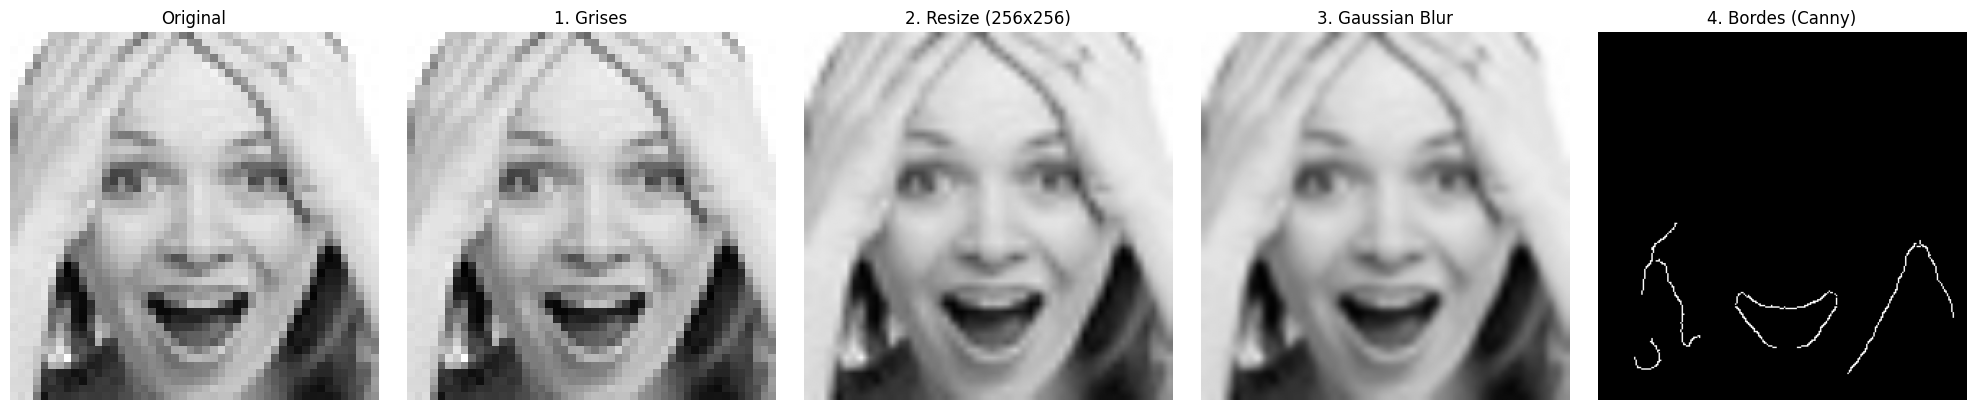

In [3]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Buscamos una imagen de prueba del dataset descargado
ruta_prueba_dir = '/content/dataset_sent_ia/facial emotion recognition/train/surprise'
archivo_prueba = os.listdir(ruta_prueba_dir)[0]
ruta_img = os.path.join(ruta_prueba_dir, archivo_prueba)
img_prueba = cv2.imread(ruta_img)

if img_prueba is not None:
    #Convertir a escala de grises
    gray = cv2.cvtColor(img_prueba, cv2.COLOR_BGR2GRAY)

    #redimensionamos
    resized = cv2.resize(gray, (256, 256))

    #sacamos el ruido de la imagen
    blur = cv2.GaussianBlur(resized, (7, 7), 0)

    #evaluamos algoritmos sobel y canny
    sobelx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    canny = cv2.Canny(blur, 100, 200)

    fig, ax = plt.subplots(1, 5, figsize=(20, 4))
    ax[0].imshow(cv2.cvtColor(img_prueba, cv2.COLOR_BGR2RGB)); ax[0].set_title("Original")
    ax[1].imshow(gray, cmap="gray"); ax[1].set_title("1. Grises")
    ax[2].imshow(resized, cmap="gray"); ax[2].set_title("2. Resize (256x256)")
    ax[3].imshow(blur, cmap="gray"); ax[3].set_title("3. Gaussian Blur")
    ax[4].imshow(canny, cmap="gray"); ax[4].set_title("4. Bordes (Canny)")

    for a in ax: a.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No se pudo cargar la imagen")

In [4]:
# PROCESAMIENTO DEL DATASET
ruta_dataset = '/content/dataset_sent_ia/facial emotion recognition/train'
clases_sent_ia = ['surprised', 'happy', 'fear', 'sad']

X_data = []
y_labels = []

for label_idx, emocion in enumerate(clases_sent_ia):
    ruta_emocion = os.path.join(ruta_dataset, emocion)

    if os.path.exists(ruta_emocion):
        print(f"cargando clase: {emocion}")
        for archivo in os.listdir(ruta_emocion):
            img = cv2.imread(os.path.join(ruta_emocion, archivo))
            if img is None: continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            resized = cv2.resize(gray, (256, 256))
            blur = cv2.GaussianBlur(resized, (7, 7), 0)

            #agregamos extracción de bordes como dato de entrenamiento
            canny = cv2.Canny(blur, 100, 200)
            X_data.append(canny)
            y_labels.append(label_idx)



cargando clase: happy
cargando clase: fear
cargando clase: sad


In [5]:
#NORMALIZACION Y EXPORTACIÓN PARA LA RED NEURONAL

X_data = np.array(X_data)
y_labels = np.array(y_labels)

# normalizamos los valores de los píxeles a una escala de 0 a 1
X_data = X_data / 255.0

#guardamos los archivos unificados
np.save('/content/X_data_SENTIA.npy', X_data)
np.save('/content/y_labels_SENTIA.npy', y_labels)


In [ ]:
#CNN
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

#cargamos los tensores que guardamos anteriormente
X = np.load('/content/X_data_SENTIA.npy')
y = np.load('/content/y_labels_SENTIA.npy')

X = X.reshape(-1, 256, 256, 1)

# dataset de entrenamiento y validacion 80/20
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"cantidad de imagenes en entrenamiento: {X_train.shape}")
print(f"cantidad de imagenes para la validación: {X_val.shape}")

#CNN
"""con la primera capa neuronal extreríamos los patrones basicos de las imágenes
    pero el colab acá nos esta fallando porque no dan los recursos del IDE para entrenar
    las capas neuronales"""
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 1)),
    layers.MaxPooling2D((2, 2)),
    #en la segunda capa extraemos formas mas complejas como ojos o nariz
    #layers.Conv2D(64, (3, 3), activation='relu'),
    #layers.MaxPooling2D((2, 2)),


    #pasamos la matriz del plano 2D a un vector 1D para las capas neuronales
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
#entrenamos
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))